# Behavioral Learning Training

## Objective: Build, train, evaluate and export TCN model for behavioral learning

This notebook implements a Temporal Convolutional Network (TCN) to learn driving behavior from telemetry data.

**Key Parameters:**
- T = 60 timesteps (6 seconds window)
- STRIDE = 10 (sliding window step)
- Input features: Speed, RPM, Distance, Position (CarX, CarY, CarZ)
- Output targets: Throttle, Brake, Steering, Gear

---
## Section 0: Imports and Configuration

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

In [2]:
# Configuration
ROOT = Path.cwd().parents[1]
DATA_DIR = ROOT / 'data' / 'processed' / 'BL-train-val-test'
SPLITS_DIR = DATA_DIR / 'splits'
FIGS_DIR = DATA_DIR / 'figs'
METADATA_DIR = DATA_DIR / 'metadata'
MODELS_DIR = ROOT / 'models' / 'behavioral-learning'

# Create directories if they don't exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

# Temporal parameters from N00
T = 60  # Window size (timesteps)
STRIDE = 10  # Sliding window stride

# Training parameters
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"T={T}, STRIDE={STRIDE}")
print(f"Batch size: {BATCH_SIZE}, LR: {LEARNING_RATE}, Epochs: {NUM_EPOCHS}")

Device: cuda
T=60, STRIDE=10
Batch size: 128, LR: 0.001, Epochs: 50


---
## Section 1: Data Loading and Preprocessing

### Load split datasets

In [3]:
def load_split_data(splits_dir):
    """
    Load train, validation and test splits from CSV files.
    
    Args:
        splits_dir: Path to directory containing split CSV files
        
    Returns:
        Dictionary with train, val, test DataFrames
    """
    splits = {}
    for split_name in ['train', 'val', 'test']:
        file_path = splits_dir / f'{split_name}_split.csv'
        df = pd.read_csv(file_path)
        splits[split_name] = df
        print(f"Loaded {split_name}: {len(df)} samples, {df['lap_id'].nunique()} laps")
    return splits

In [4]:
splits = load_split_data(SPLITS_DIR)

Loaded train: 252588 samples, 307 laps
Loaded val: 53350 samples, 65 laps
Loaded test: 55062 samples, 67 laps


### Define features and targets

In [5]:
# Input features: State information
FEATURE_COLS = ['Speed_kmh', 'RPM', 'Distance', 'CarX', 'CarY', 'CarZ', 'Gear']

# Output targets: Control actions
TARGET_COLS = ['Throttle', 'Brake', 'Steering']

# Metadata columns
META_COLS = ['lap_id', 'iCurrentTime_ms']

print(f"Input features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Output targets ({len(TARGET_COLS)}): {TARGET_COLS}")

Input features (7): ['Speed_kmh', 'RPM', 'Distance', 'CarX', 'CarY', 'CarZ', 'Gear']
Output targets (3): ['Throttle', 'Brake', 'Steering']


### Feature normalization

In [6]:
def fit_scalers(train_df, feature_cols, target_cols):
    """
    Fit StandardScaler on training data for features and targets.
    
    Args:
        train_df: Training DataFrame
        feature_cols: List of feature column names
        target_cols: List of target column names
        
    Returns:
        Tuple of (feature_scaler, target_scaler)
    """
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()
    
    feature_scaler.fit(train_df[feature_cols])
    target_scaler.fit(train_df[target_cols])
    
    print("Feature scaler fitted")
    print(f"  Mean: {feature_scaler.mean_}")
    print(f"  Std: {feature_scaler.scale_}")
    
    return feature_scaler, target_scaler

def transform_data(df, feature_cols, target_cols, feature_scaler, target_scaler):
    """
    Transform features and targets using fitted scalers.
    
    Args:
        df: DataFrame to transform
        feature_cols: List of feature column names
        target_cols: List of target column names
        feature_scaler: Fitted feature scaler
        target_scaler: Fitted target scaler
        
    Returns:
        Tuple of (scaled_features, scaled_targets) as numpy arrays
    """
    features = feature_scaler.transform(df[feature_cols])
    targets = target_scaler.transform(df[target_cols])
    return features, targets

In [7]:
# Fit scalers on training data
feature_scaler, target_scaler = fit_scalers(splits['train'], FEATURE_COLS, TARGET_COLS)

# Save scalers for later use
import pickle
with open(MODELS_DIR / 'feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)
with open(MODELS_DIR / 'target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)
print("Scalers saved")

Feature scaler fitted
  Mean: [ 2.49610203e+02  1.08157450e+04  2.80049912e+03  2.40278047e+02
 -4.45425038e+00 -3.88024734e+02  6.17409378e+00]
  Std: [  71.56627993 1326.47992795 1635.25478352  408.18254018    3.6252532
  669.36673087    2.03769915]
Scalers saved


---
## Section 2: Dataset Implementation with Sliding Windows

In [8]:
class TelemetryWindowDataset(Dataset):
    """
    PyTorch Dataset for telemetry data with sliding windows.
    
    Creates windows of T timesteps from telemetry sequences, grouped by lap_id.
    Each window uses the last timestep as the prediction target.
    """
    
    def __init__(self, df, feature_cols, target_cols, feature_scaler, target_scaler, 
                 window_size=60, stride=10):
        """
        Args:
            df: DataFrame with telemetry data
            feature_cols: List of feature column names
            target_cols: List of target column names
            feature_scaler: Fitted StandardScaler for features
            target_scaler: Fitted StandardScaler for targets
            window_size: Number of timesteps per window (T)
            stride: Step size for sliding window
        """
        self.window_size = window_size
        self.stride = stride
        self.feature_cols = feature_cols
        self.target_cols = target_cols
        
        # Transform data
        features, targets = transform_data(df, feature_cols, target_cols, 
                                          feature_scaler, target_scaler)
        
        # Store lap_ids for grouping
        self.lap_ids = df['lap_id'].values
        self.features = features
        self.targets = targets
        
        # Generate window indices
        self.windows = self._generate_windows()
        
    def _generate_windows(self):
        """
        Generate sliding window indices grouped by lap_id.
        
        Returns:
            List of tuples (start_idx, end_idx) for each valid window
        """
        windows = []
        unique_laps = np.unique(self.lap_ids)
        
        for lap_id in unique_laps:
            # Get indices for this lap
            lap_mask = self.lap_ids == lap_id
            lap_indices = np.where(lap_mask)[0]
            
            # Generate sliding windows for this lap
            lap_start = lap_indices[0]
            lap_end = lap_indices[-1]
            lap_length = lap_end - lap_start + 1
            
            # Create windows with stride
            for i in range(0, lap_length - self.window_size + 1, self.stride):
                window_start = lap_start + i
                window_end = window_start + self.window_size
                windows.append((window_start, window_end))
        
        return windows
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        """
        Get a single window sample.
        
        Returns:
            Tuple of (X, y) where:
            - X: [window_size, num_features] sequence of features
            - y: [num_targets] target values at last timestep
        """
        start_idx, end_idx = self.windows[idx]
        
        # Get feature window [T, num_features]
        X = self.features[start_idx:end_idx]
        
        # Get target at last timestep [num_targets]
        y = self.targets[end_idx - 1]
        
        return torch.FloatTensor(X), torch.FloatTensor(y)

### Create datasets and dataloaders

In [9]:
# Create datasets
train_dataset = TelemetryWindowDataset(
    splits['train'], FEATURE_COLS, TARGET_COLS, 
    feature_scaler, target_scaler, 
    window_size=T, stride=STRIDE
)

val_dataset = TelemetryWindowDataset(
    splits['val'], FEATURE_COLS, TARGET_COLS,
    feature_scaler, target_scaler,
    window_size=T, stride=STRIDE
)

test_dataset = TelemetryWindowDataset(
    splits['test'], FEATURE_COLS, TARGET_COLS,
    feature_scaler, target_scaler,
    window_size=T, stride=STRIDE
)

print(f"Train windows: {len(train_dataset)}")
print(f"Val windows: {len(val_dataset)}")
print(f"Test windows: {len(test_dataset)}")

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test dataloader
sample_X, sample_y = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  X: {sample_X.shape} [batch, time, features]")
print(f"  y: {sample_y.shape} [batch, targets]")

Train windows: 23539
Val windows: 4970
Test windows: 5130

Sample batch shapes:
  X: torch.Size([128, 60, 7]) [batch, time, features]
  y: torch.Size([128, 3]) [batch, targets]


---
## Section 3: TCN Architecture Implementation

### Temporal Convolutional Network components

In [10]:
class CausalConv1d(nn.Module):
    """
    Causal 1D convolution: ensures output at time t depends only on inputs up to time t.
    """
    
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, 
                             padding=self.padding, dilation=dilation)
        
    def forward(self, x):
        # Apply convolution and remove future padding
        out = self.conv(x)
        if self.padding > 0:
            out = out[:, :, :-self.padding]
        return out


class TemporalBlock(nn.Module):
    """
    Single temporal block with two causal convolutions, residual connection.
    """
    
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        
        # First causal conv layer
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        # Second causal conv layer
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        # Residual connection with 1x1 conv if needed
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu_out = nn.ReLU()
        
    def forward(self, x):
        # Main path
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.dropout1(out)
        
        out = self.conv2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        
        # Residual connection
        res = x if self.residual is None else self.residual(x)
        
        return self.relu_out(out + res)


class TCN(nn.Module):
    """
    Temporal Convolutional Network for behavioral learning.
    
    Stacks multiple temporal blocks with increasing dilation to capture
    long-range temporal dependencies efficiently.
    """
    
    def __init__(self, input_size, output_size, num_channels=[64, 128, 128, 64], 
                 kernel_size=3, dropout=0.2):
        """
        Args:
            input_size: Number of input features
            output_size: Number of output targets
            num_channels: List of channel sizes for each temporal block
            kernel_size: Kernel size for convolutions
            dropout: Dropout probability
        """
        super().__init__()
        
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation = 2 ** i  # Exponentially increasing dilation
            in_channels = input_size if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            
            layers.append(TemporalBlock(in_channels, out_channels, kernel_size, 
                                       dilation, dropout))
        
        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(num_channels[-1], output_size)
        
    def forward(self, x):
        """
        Args:
            x: [batch, time, features] input tensor
            
        Returns:
            [batch, output_size] predictions for last timestep
        """
        # Transpose to [batch, features, time] for conv1d
        x = x.transpose(1, 2)
        
        # Apply TCN blocks
        out = self.network(x)
        
        # Take last timestep and apply output layer
        out = out[:, :, -1]  # [batch, channels]
        out = self.output_layer(out)  # [batch, output_size]
        
        return out

### Initialize model

In [11]:
# Model configuration
INPUT_SIZE = len(FEATURE_COLS)
OUTPUT_SIZE = len(TARGET_COLS)
NUM_CHANNELS = [64, 128, 128, 64]  # Channel sizes for each temporal block
KERNEL_SIZE = 3
DROPOUT = 0.2

# Create model
model = TCN(
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE,
    num_channels=NUM_CHANNELS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model created:")
print(f"  Input size: {INPUT_SIZE}")
print(f"  Output size: {OUTPUT_SIZE}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Model created:
  Input size: 7
  Output size: 3
  Total parameters: 240,579
  Trainable parameters: 240,579

Model architecture:
TCN(
  (network): Sequential(
    (0): TemporalBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(7, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (residual): Conv1d(7, 64, kernel_size=(1,), stride=(1,))
      (relu_out): ReLU()
    )
    (1): TemporalBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      )
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): CausalConv1d(
        (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      )
     

---
## Section 4: Training Setup

### Loss function and optimizer

In [12]:
# Loss function: MSE for regression
criterion = nn.MSELoss()

# Optimizer: Adam
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler: reduce on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("Training setup complete")
print(f"  Loss: MSE")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Scheduler: ReduceLROnPlateau")

Training setup complete
  Loss: MSE
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau


### Training and validation functions

In [13]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train model for one epoch.
    
    Args:
        model: PyTorch model
        dataloader: Training dataloader
        criterion: Loss function
        optimizer: Optimizer
        device: Device to use
        
    Returns:
        Average loss over epoch
    """
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches


def validate_epoch(model, dataloader, criterion, device):
    """
    Validate model on validation set.
    
    Args:
        model: PyTorch model
        dataloader: Validation dataloader
        criterion: Loss function
        device: Device to use
        
    Returns:
        Average loss over validation set
    """
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            
            outputs = model(X)
            loss = criterion(outputs, y)
            
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches


def train_model(model, train_loader, val_loader, criterion, optimizer, 
                scheduler, num_epochs, device, save_dir):
    """
    Complete training loop with validation and checkpointing.
    
    Args:
        model: PyTorch model
        train_loader: Training dataloader
        val_loader: Validation dataloader
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of epochs
        device: Device to use
        save_dir: Directory to save checkpoints
        
    Returns:
        Dictionary with training history
    """
    history = {
        'train_loss': [],
        'val_loss': [],
        'learning_rates': []
    }
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['learning_rates'].append(current_lr)
        
        # Print progress
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss: {val_loss:.6f}")
        print(f"  LR: {current_lr:.6f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
            }, save_dir / 'best_model.pth')
            print(f"  ✓ Best model saved (val_loss: {val_loss:.6f})")
        
        print()
    
    return history

---
## Section 5: Model Training

In [14]:
# Train the model
print("Starting training...\n")
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    save_dir=MODELS_DIR
)

print("Training complete!")

Starting training...

Epoch 1/50
  Train Loss: 0.285290
  Val Loss: 0.093173
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.093173)

Epoch 2/50
  Train Loss: 0.097312
  Val Loss: 0.067685
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.067685)

Epoch 3/50
  Train Loss: 0.079010
  Val Loss: 0.062259
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.062259)

Epoch 4/50
  Train Loss: 0.070579
  Val Loss: 0.053141
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.053141)

Epoch 5/50
  Train Loss: 0.066083
  Val Loss: 0.051306
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.051306)

Epoch 6/50
  Train Loss: 0.060686
  Val Loss: 0.050425
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.050425)

Epoch 7/50
  Train Loss: 0.056985
  Val Loss: 0.045398
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.045398)

Epoch 8/50
  Train Loss: 0.053860
  Val Loss: 0.045627
  LR: 0.001000

Epoch 9/50
  Train Loss: 0.051429
  Val Loss: 0.038912
  LR: 0.001000
  ✓ Best model saved (val_loss: 0.038912)

Epo

### Save training history

In [15]:
# Save history to JSON
with open(MODELS_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
    
print("Training history saved")

Training history saved


---
## Section 6: Evaluation Metrics

### Load best model

In [16]:
# Load best model checkpoint
checkpoint = torch.load(MODELS_DIR / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model loaded (epoch {checkpoint['epoch']}, val_loss: {checkpoint['val_loss']:.6f})")

Best model loaded (epoch 45, val_loss: 0.024743)


### Compute detailed metrics on test set

In [17]:
def compute_predictions(model, dataloader, device):
    """
    Compute predictions for entire dataset.
    
    Args:
        model: Trained PyTorch model
        dataloader: DataLoader for dataset
        device: Device to use
        
    Returns:
        Tuple of (predictions, targets) as numpy arrays
    """
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            outputs = model(X)
            
            all_predictions.append(outputs.cpu().numpy())
            all_targets.append(y.numpy())
    
    predictions = np.vstack(all_predictions)
    targets = np.vstack(all_targets)
    
    return predictions, targets


def calculate_metrics(predictions, targets, target_names):
    """
    Calculate regression metrics per target.
    
    Args:
        predictions: Predicted values [N, num_targets]
        targets: True values [N, num_targets]
        target_names: List of target names
        
    Returns:
        Dictionary with metrics per target
    """
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    metrics = {}
    
    for i, name in enumerate(target_names):
        y_true = targets[:, i]
        y_pred = predictions[:, i]
        
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics[name] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }
    
    # Overall metrics
    overall_mse = mean_squared_error(targets, predictions)
    overall_rmse = np.sqrt(overall_mse)
    overall_mae = mean_absolute_error(targets, predictions)
    overall_r2 = r2_score(targets, predictions)
    
    metrics['Overall'] = {
        'MSE': overall_mse,
        'RMSE': overall_rmse,
        'MAE': overall_mae,
        'R2': overall_r2
    }
    
    return metrics


def print_metrics(metrics):
    """
    Print metrics in formatted table.
    
    Args:
        metrics: Dictionary with metrics per target
    """
    print("\n" + "="*60)
    print("EVALUATION METRICS")
    print("="*60)
    
    for target_name, target_metrics in metrics.items():
        print(f"\n{target_name}:")
        for metric_name, value in target_metrics.items():
            print(f"  {metric_name:6s}: {value:8.6f}")
    
    print("\n" + "="*60)

In [18]:
# Evaluate on test set
print("Computing test predictions...")
test_predictions, test_targets = compute_predictions(model, test_loader, DEVICE)

print("Calculating metrics...")
test_metrics = calculate_metrics(test_predictions, test_targets, TARGET_COLS)

print_metrics(test_metrics)

# Save metrics
with open(MODELS_DIR / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)
print("\nMetrics saved to test_metrics.json")

Computing test predictions...
Calculating metrics...

EVALUATION METRICS

Throttle:
  MSE   : 0.065985
  RMSE  : 0.256875
  MAE   : 0.075747
  R2    : 0.940568

Brake:
  MSE   : 0.018460
  RMSE  : 0.135868
  MAE   : 0.031596
  R2    : 0.984022

Steering:
  MSE   : 0.005784
  RMSE  : 0.076053
  MAE   : 0.035062
  R2    : 0.995323

Overall:
  MSE   : 0.030076
  RMSE  : 0.173425
  MAE   : 0.047468
  R2    : 0.973304


Metrics saved to test_metrics.json


---
## Section 7: Visualization and Analysis

### Training curves

Figure saved to c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\processed\BL-train-val-test\figs\training_curves.png


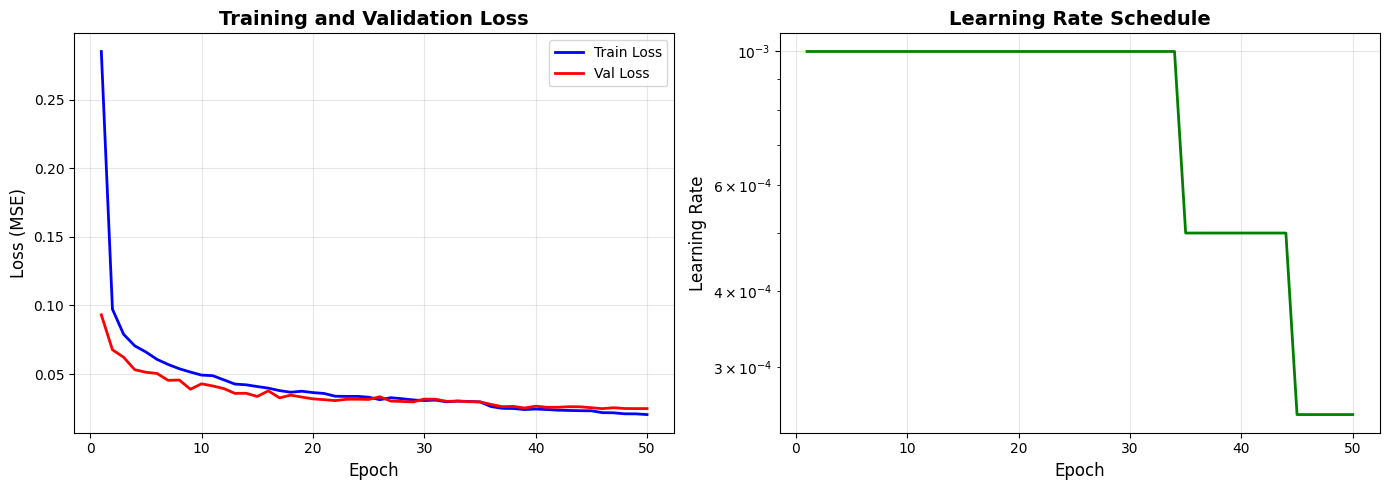

In [19]:
def plot_training_curves(history, save_path=None):
    """
    Plot training and validation loss curves.
    
    Args:
        history: Dictionary with training history
        save_path: Optional path to save figure
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss curves
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss (MSE)', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Learning rate
    ax2.plot(epochs, history['learning_rates'], 'g-', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Learning Rate', fontsize=12)
    ax2.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

plot_training_curves(history, FIGS_DIR / 'training_curves.png')

### Prediction vs actual comparison

Figure saved to c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\processed\BL-train-val-test\figs\prediction_comparison.png


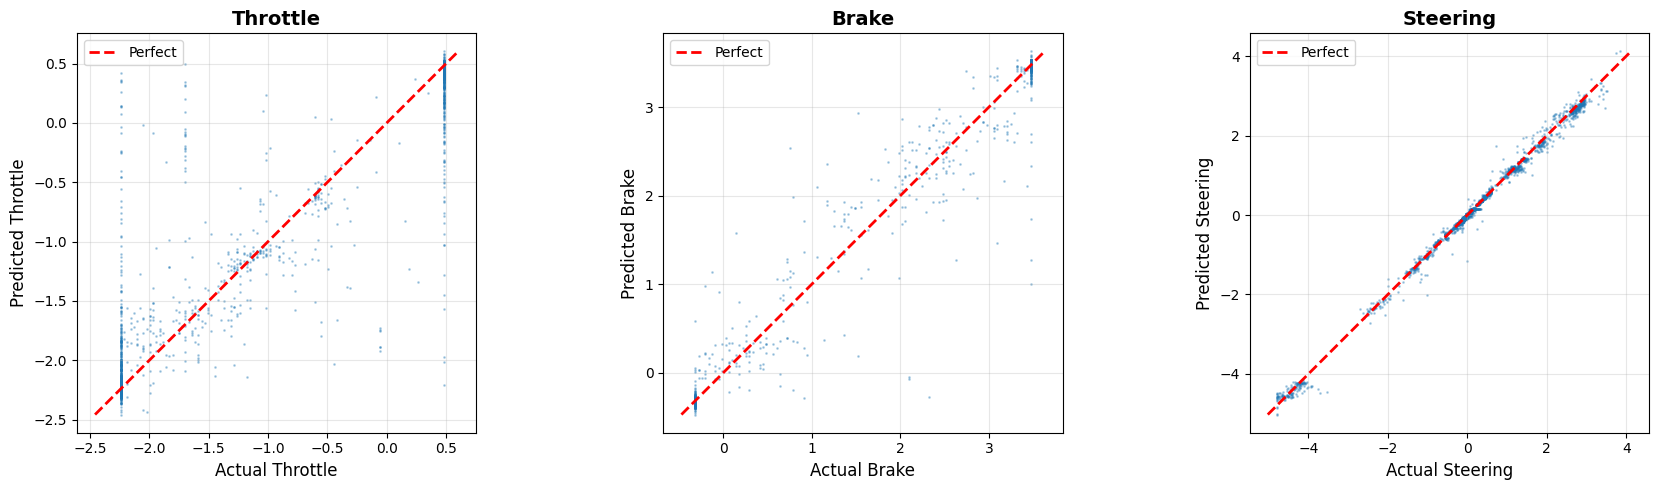

In [20]:
def plot_prediction_comparison(predictions, targets, target_names, save_path=None):
    """
    Plot predicted vs actual values for each target.
    
    Args:
        predictions: Predicted values [N, num_targets]
        targets: True values [N, num_targets]
        target_names: List of target names
        save_path: Optional path to save figure
    """
    num_targets = len(target_names)
    fig, axes = plt.subplots(1, num_targets, figsize=(6*num_targets, 5))
    
    if num_targets == 1:
        axes = [axes]
    
    for i, (ax, name) in enumerate(zip(axes, target_names)):
        y_true = targets[:, i]
        y_pred = predictions[:, i]
        
        # Scatter plot
        ax.scatter(y_true, y_pred, alpha=0.3, s=1)
        
        # Perfect prediction line
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
        
        ax.set_xlabel(f'Actual {name}', fontsize=12)
        ax.set_ylabel(f'Predicted {name}', fontsize=12)
        ax.set_title(f'{name}', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

plot_prediction_comparison(test_predictions, test_targets, TARGET_COLS, 
                          FIGS_DIR / 'prediction_comparison.png')

### Error distribution analysis

Figure saved to c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\processed\BL-train-val-test\figs\error_distribution.png


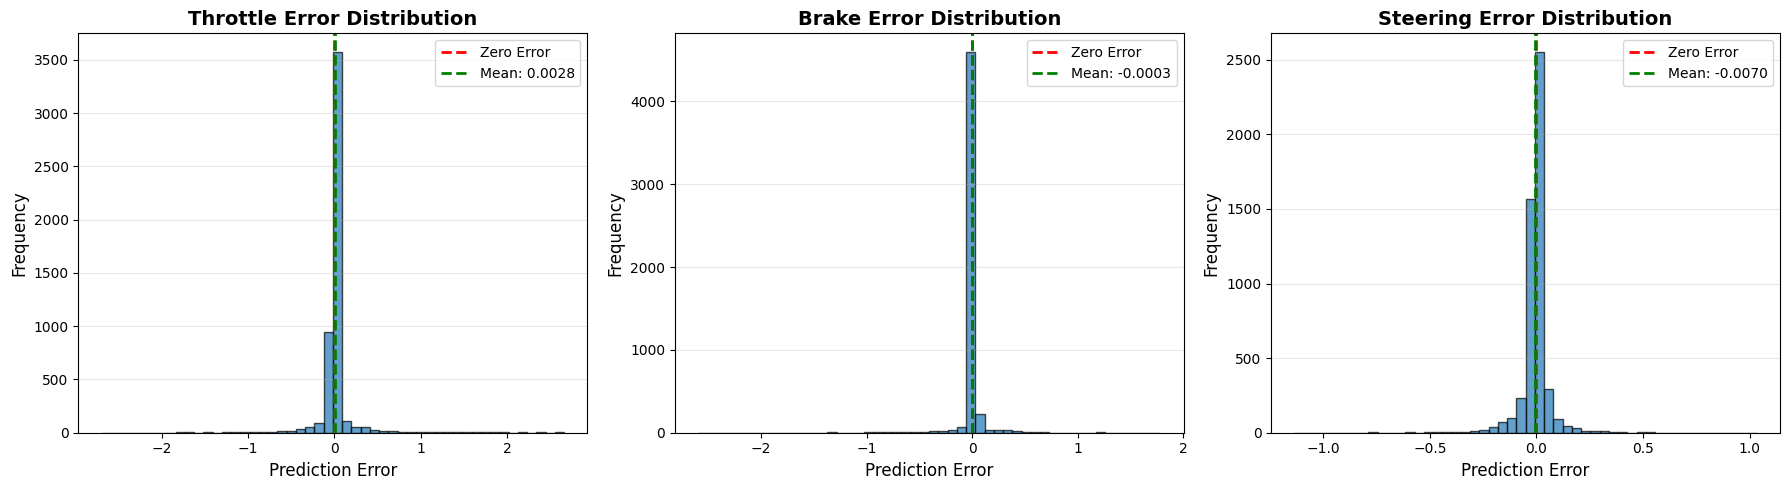

In [21]:
def plot_error_distribution(predictions, targets, target_names, save_path=None):
    """
    Plot error distribution histograms for each target.
    
    Args:
        predictions: Predicted values [N, num_targets]
        targets: True values [N, num_targets]
        target_names: List of target names
        save_path: Optional path to save figure
    """
    num_targets = len(target_names)
    fig, axes = plt.subplots(1, num_targets, figsize=(6*num_targets, 5))
    
    if num_targets == 1:
        axes = [axes]
    
    for i, (ax, name) in enumerate(zip(axes, target_names)):
        errors = predictions[:, i] - targets[:, i]
        
        ax.hist(errors, bins=50, alpha=0.7, edgecolor='black')
        ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero Error')
        ax.axvline(errors.mean(), color='g', linestyle='--', linewidth=2, 
                  label=f'Mean: {errors.mean():.4f}')
        
        ax.set_xlabel('Prediction Error', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title(f'{name} Error Distribution', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

plot_error_distribution(test_predictions, test_targets, TARGET_COLS,
                       FIGS_DIR / 'error_distribution.png')

### Sample prediction timeline

Figure saved to c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\processed\BL-train-val-test\figs\sample_timeline.png


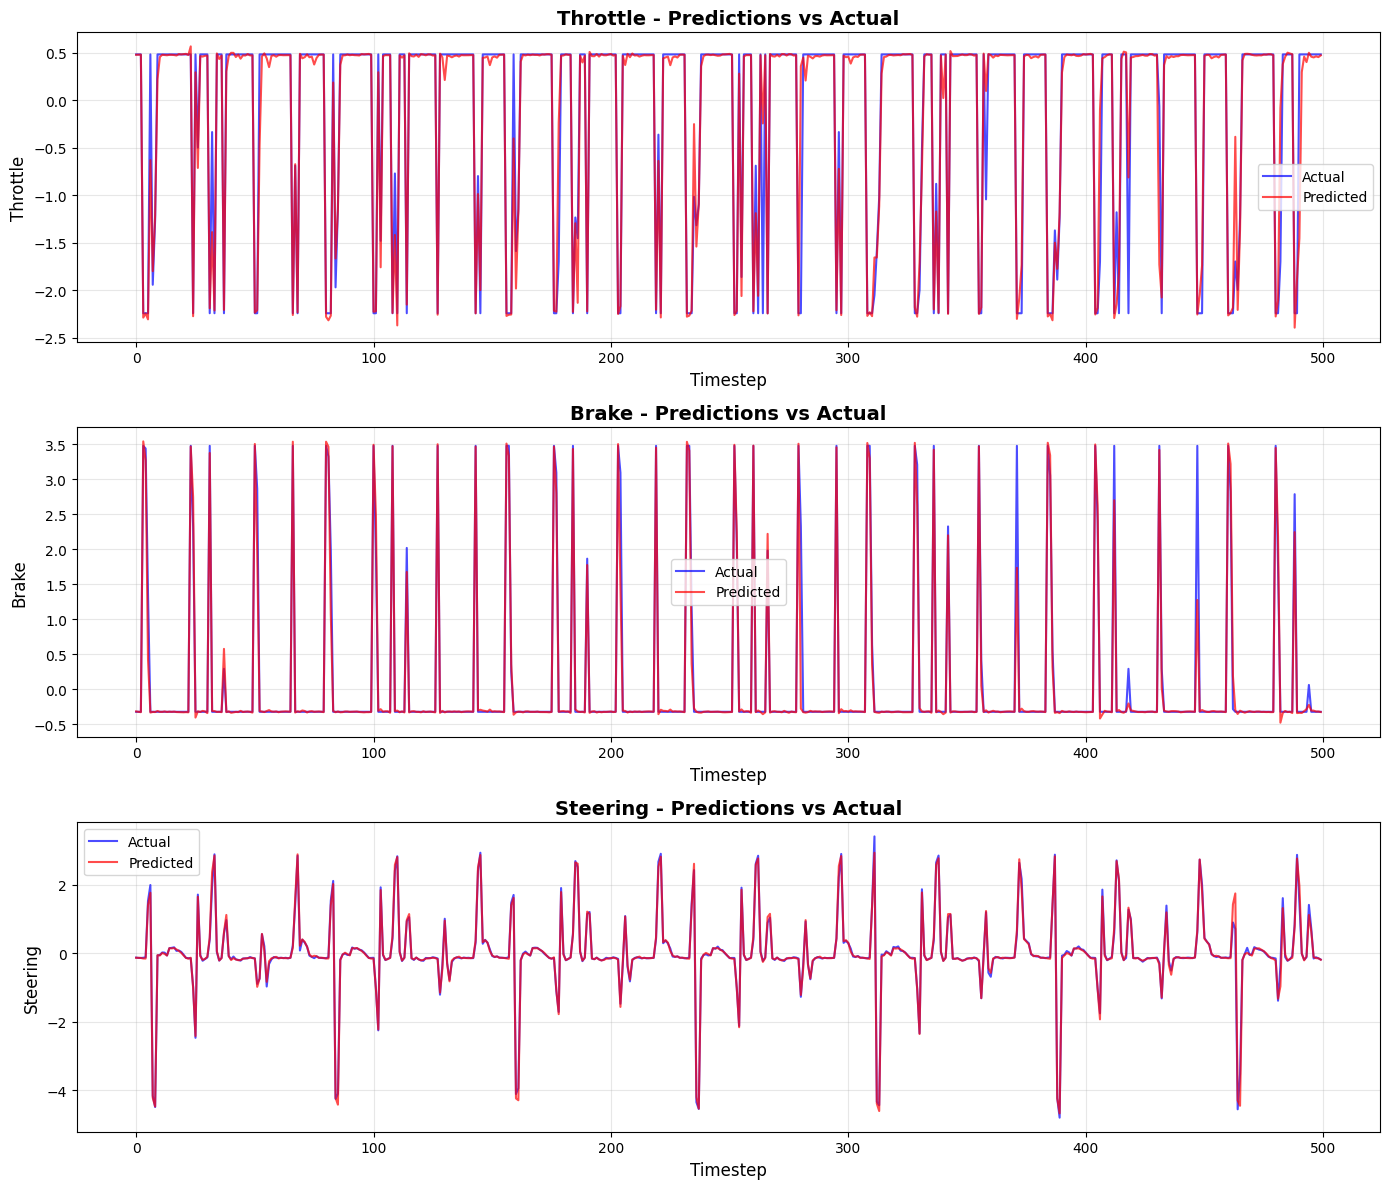

In [22]:
def plot_sample_predictions(predictions, targets, target_names, num_samples=500, save_path=None):
    """
    Plot timeline of predictions vs actual for sample data.
    
    Args:
        predictions: Predicted values [N, num_targets]
        targets: True values [N, num_targets]
        target_names: List of target names
        num_samples: Number of samples to plot
        save_path: Optional path to save figure
    """
    num_targets = len(target_names)
    fig, axes = plt.subplots(num_targets, 1, figsize=(14, 4*num_targets))
    
    if num_targets == 1:
        axes = [axes]
    
    sample_idx = slice(0, num_samples)
    timesteps = range(num_samples)
    
    for i, (ax, name) in enumerate(zip(axes, target_names)):
        ax.plot(timesteps, targets[sample_idx, i], 'b-', label='Actual', linewidth=1.5, alpha=0.7)
        ax.plot(timesteps, predictions[sample_idx, i], 'r-', label='Predicted', linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Timestep', fontsize=12)
        ax.set_ylabel(name, fontsize=12)
        ax.set_title(f'{name} - Predictions vs Actual', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

plot_sample_predictions(test_predictions, test_targets, TARGET_COLS, num_samples=500,
                       save_path=FIGS_DIR / 'sample_timeline.png')

### Metrics summary table

In [23]:
def create_metrics_table(metrics):
    """
    Create formatted DataFrame of metrics.
    
    Args:
        metrics: Dictionary with metrics per target
        
    Returns:
        DataFrame with formatted metrics
    """
    metrics_df = pd.DataFrame(metrics).T
    return metrics_df

metrics_table = create_metrics_table(test_metrics)
print("\nTest Set Metrics Summary:")
print(metrics_table.to_string())

# Save to CSV
metrics_table.to_csv(METADATA_DIR / 'test_metrics_table.csv')
print(f"\nMetrics table saved to {METADATA_DIR / 'test_metrics_table.csv'}")


Test Set Metrics Summary:
               MSE      RMSE       MAE        R2
Throttle  0.065985  0.256875  0.075747  0.940568
Brake     0.018460  0.135868  0.031596  0.984022
Steering  0.005784  0.076053  0.035062  0.995323
Overall   0.030076  0.173425  0.047468  0.973304

Metrics table saved to c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\processed\BL-train-val-test\metadata\test_metrics_table.csv


---
## Section 8: Model Export

### Export model weights and configuration

In [24]:
# Model configuration dictionary
model_config = {
    'architecture': 'TCN',
    'input_size': INPUT_SIZE,
    'output_size': OUTPUT_SIZE,
    'num_channels': NUM_CHANNELS,
    'kernel_size': KERNEL_SIZE,
    'dropout': DROPOUT,
    'window_size': T,
    'stride': STRIDE,
    'feature_cols': FEATURE_COLS,
    'target_cols': TARGET_COLS,
    'total_parameters': total_params,
    'trainable_parameters': trainable_params,
    'training': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'num_epochs': NUM_EPOCHS,
        'optimizer': 'Adam',
        'loss': 'MSE',
        'best_val_loss': checkpoint['val_loss'],
        'best_epoch': checkpoint['epoch']
    },
    'test_metrics': test_metrics
}

# Save configuration
with open(MODELS_DIR / 'model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Model configuration saved to model_config.json")

Model configuration saved to model_config.json


### Export final model for deployment

In [26]:
# Save full model (architecture + weights)
torch.save(model, MODELS_DIR / 'tcn_model_full.pth')
print("Full model saved to tcn_model_full.pth")

# Save state dict only (recommended for deployment)
torch.save(model.state_dict(), MODELS_DIR / 'tcn_model_weights.pth')
print("Model weights saved to tcn_model_weights.pth")

# Export to ONNX format (for cross-platform deployment)
dummy_input = torch.randn(1, T, INPUT_SIZE).to(DEVICE)
torch.onnx.export(
    model,
    dummy_input,
    MODELS_DIR / 'tcn_model.onnx',
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Model exported to ONNX format: tcn_model.onnx")

Full model saved to tcn_model_full.pth
Model weights saved to tcn_model_weights.pth


C:\Users\victo\AppData\Local\Temp\ipykernel_23176\3169288536.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1206 17:06:26.264000 23176 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\victo\miniconda3\envs\F1_AC_Digital_Twin_env\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\victo\miniconda3\envs\F1_AC_Digital_Twin_env\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\victo\miniconda3\envs\F1_AC_Digital_Twin_env\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 9 of general pattern rewrite rules.
Model exported to ONNX format: tcn_model.onnx


### Create deployment package summary

In [ ]:
print("\n" + "="*60)
print("MODEL EXPORT SUMMARY")
print("="*60)
print(f"\nModel artifacts saved to: {MODELS_DIR}")
print("\nFiles created:")
print("  1. best_model.pth - Training checkpoint with optimizer state")
print("  2. tcn_model_full.pth - Full PyTorch model (architecture + weights)")
print("  3. tcn_model_weights.pth - Model weights only (state dict)")
print("  4. tcn_model.onnx - ONNX format for deployment")
print("  5. model_config.json - Model configuration and metadata")
print("  6. training_history.json - Training curves data")
print("  7. test_metrics.json - Evaluation metrics")
print("  8. feature_scaler.pkl - Feature normalization scaler")
print("  9. target_scaler.pkl - Target normalization scaler")
print("\nVisualization files saved to: {}".format(FIGS_DIR))
print("  - training_curves.png")
print("  - prediction_comparison.png")
print("  - error_distribution.png")
print("  - sample_timeline.png")
print("\n" + "="*60)
print("✓ Training pipeline complete!")
print("="*60)

---
## Summary

This notebook implemented a complete behavioral learning pipeline:

1. **Data Loading**: Loaded train/val/test splits from N00_BL_data_split
2. **Preprocessing**: Normalized features and targets using StandardScaler
3. **Dataset Creation**: Implemented sliding window dataset with T=60, stride=10
4. **TCN Architecture**: Built Temporal Convolutional Network with causal convolutions
5. **Training**: Trained model with Adam optimizer and learning rate scheduling
6. **Evaluation**: Computed comprehensive metrics on test set
7. **Visualization**: Generated training curves and prediction analysis plots
8. **Export**: Saved model weights, configuration, and deployment files

**Next Steps:**
- Deploy model for real-time inference
- Integrate with AC simulation environment
- Test behavioral cloning in live racing scenarios